In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

RAW_DATA_PATH = "ai_agent_performance_dataset.csv"
OUTPUT_CSV_PATH = "agent_health_report_ml.csv"
N_CLUSTERS = 4  # Top Performer / Solid / Needs Improvement / Underperforming

In [2]:
df = pd.read_csv(RAW_DATA_PATH)
print(f"Loaded {len(df)} conversations for {df['agent_name'].nunique()} agents.")
df.head()

Loaded 10000 conversations for 12 agents.


,conversation_id,agent_name,agent_domain,department_industry,query_type,conversation_date,resolution_time_sec,resolution_status,escalated,customer_satisfaction,tokens_used,cost_per_conversation_usd,response_consistency_score,repetitive_response_flag
0,CONV005260,SupportBot-v4,Customer Support,Manufacturing,Refund Request,2025-01-01 00:10:00,128.0,Resolved,No,4.7,700,0.0467,93.6,No
1,CONV005180,KnowledgeFinder-Lite,Internal Knowledge Search,Banking,Document Search,2025-01-01 00:12:00,119.7,Resolved,No,3.3,264,0.0240,84.3,No
2,CONV007485,KnowledgeFinder-Lite,Internal Knowledge Search,Retail,Policy Lookup,2025-01-01 00:21:00,149.0,Resolved,No,3.0,231,0.0223,70.9,No
3,CONV009292,SupportBot-v3,Customer Support,Telecom,Refund Request,2025-01-01 00:35:00,143.0,Resolved,No,4.0,957,0.0552,84.2,No
4,CONV002315,SupportBot-v3,Customer Support,Banking,Refund Request,2025-01-01 00:39:00,69.9,Resolved,No,4.2,256,0.0287,85.8,No


In [3]:
def pct_yes(series):
    return (series == "Yes").mean() * 100

agent = df.groupby("agent_name").agg(
    agent_domain=("agent_domain", "first"),
    total_conversations=("agent_name", "count"),
    resolution_rate=("resolution_status", lambda s: (s == "Resolved").mean() * 100),
    escalation_rate=("escalated", pct_yes),
    avg_satisfaction=("customer_satisfaction", "mean"),
    avg_tokens=("tokens_used", "mean"),
    avg_cost_per_conv=("cost_per_conversation_usd", "mean"),
    avg_consistency=("response_consistency_score", "mean"),
    repetitive_rate=("repetitive_response_flag", pct_yes),
).reset_index()

agent

,agent_name,agent_domain,total_conversations,resolution_rate,escalation_rate,avg_satisfaction,avg_tokens,avg_cost_per_conv,avg_consistency,repetitive_rate
0,HR-FAQ-Agent,HR Queries,798,84.085213,9.649123,3.900125,483.184211,0.034246,86.250752,6.766917
1,HRQueryBot,HR Queries,799,85.732165,7.634543,4.088360,407.770964,0.029877,88.140426,5.256571
2,IT-Legacy-Bot,IT Helpdesk,509,76.817289,16.895874,2.998625,597.717092,0.044037,78.991159,14.734774
3,ITHelpDesk-AI,IT Helpdesk,508,78.346457,15.157480,3.426181,550.458661,0.040726,82.346850,11.811024
4,KnowledgeFinder-Lite,Internal Knowledge Search,726,84.848485,9.090909,3.607713,472.723140,0.034968,83.941185,11.157025
5,KnowledgeFinder-X,Internal Knowledge Search,877,91.220068,3.534778,4.457583,436.059293,0.031741,90.850513,2.964652
6,OmniAssist-2,Customer Support,1173,87.723785,5.967604,4.238875,454.714408,0.032787,88.763512,5.115090
7,SalesAssist-Lite,Sales Assistance,696,79.454023,14.224138,3.223420,505.489943,0.036214,80.907040,14.080460
8,SalesAssist-Pro,Sales Assistance,1033,87.512101,5.711520,4.337076,446.838335,0.032828,89.735140,3.678606
9,SchedulerBot,Appointment Scheduling,896,88.616071,4.687500,4.522879,394.050223,0.028946,91.320982,2.566964


In [5]:
feature_cols = [
    "resolution_rate", "escalation_rate", "avg_satisfaction",
    "avg_tokens", "avg_cost_per_conv", "avg_consistency", "repetitive_rate",
]

scaler = MinMaxScaler()
X = scaler.fit_transform(agent[feature_cols])

# Flip the "bad" metrics (cost, tokens, escalation, repetition) so that
# in every column, HIGHER always means BETTER.
bad_metric_idx = [feature_cols.index(c) for c in
                   ["escalation_rate", "avg_tokens", "avg_cost_per_conv", "repetitive_rate"]]
X[:, bad_metric_idx] = 1 - X[:, bad_metric_idx]

In [7]:
agent[['agent_name', 'agent_health_score', 'cluster']].to_csv(OUTPUT_CSV_PATH, index=False)
print(f"Saved to {OUTPUT_CSV_PATH}")

Saved to agent_health_report_ml.csv


In [12]:
# Cluster ku name kudupom
cluster_labels = {0: "Underperforming", 1: "Solid", 2: "Top Performer", 3: "Needs Improvement"}
agent['cluster_label'] = agent['cluster'].map(cluster_labels)

# CSV ah save pannu
agent[['agent_name', 'agent_health_score', 'cluster', 'cluster_label']].to_csv(OUTPUT_CSV_PATH, index=False)
print(f"✅ Saved to {OUTPUT_CSV_PATH}")

✅ Saved to agent_health_report_ml.csv


In [14]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
agent["cluster"] = kmeans.fit_predict(X)

# A single 0-100 "Agent Health Score" per agent
weights = {
    "resolution_rate": 0.20,
    "escalation_rate": 0.20,
    "avg_satisfaction": 0.30,
    "avg_tokens": 0.05,
    "avg_cost_per_conv": 0.10,
    "avg_consistency": 0.10,
    "repetitive_rate": 0.05,
}
w_vector = np.array([weights[c] for c in feature_cols])
agent["agent_health_score"] = (X * w_vector).sum(axis=1) * 100
agent["agent_health_score"] = agent["agent_health_score"].round(1)
agent[["agent_name", "agent_health_score", "cluster"]]

C:\Users\acer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,agent_name,agent_health_score,cluster
0,HR-FAQ-Agent,56.0,3
1,HRQueryBot,71.6,1
2,IT-Legacy-Bot,-0.0,0
3,ITHelpDesk-AI,19.9,0
4,KnowledgeFinder-Lite,48.6,3
5,KnowledgeFinder-X,93.4,2
6,OmniAssist-2,77.2,1
7,SalesAssist-Lite,21.1,0
8,SalesAssist-Pro,80.6,1
9,SchedulerBot,92.7,2


In [15]:
cluster_rank = (
    agent.groupby("cluster")["agent_health_score"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
status_labels = ["Top Performer", "Solid Performer", "Needs Improvement", "Underperforming"]
cluster_to_status = {cluster_rank[i]: status_labels[i] for i in range(len(cluster_rank))}
agent["performance_status"] = agent["cluster"].map(cluster_to_status)
agent[["agent_name", "agent_health_score", "performance_status"]]

,agent_name,agent_health_score,performance_status
0,HR-FAQ-Agent,56.0,Needs Improvement
1,HRQueryBot,71.6,Solid Performer
2,IT-Legacy-Bot,-0.0,Underperforming
3,ITHelpDesk-AI,19.9,Underperforming
4,KnowledgeFinder-Lite,48.6,Needs Improvement
5,KnowledgeFinder-X,93.4,Top Performer
6,OmniAssist-2,77.2,Solid Performer
7,SalesAssist-Lite,21.1,Underperforming
8,SalesAssist-Pro,80.6,Solid Performer
9,SchedulerBot,92.7,Top Performer


In [16]:
def recommended_action(row):
    if row["performance_status"] == "Top Performer":
        return "Expand deployment across customer support teams."
    scaled_row = X[agent.index[agent["agent_name"] == row["agent_name"]][0]]
    weakest_idx = scaled_row.argmin()
    weakest_metric = feature_cols[weakest_idx]
    if weakest_metric in ["avg_cost_per_conv", "avg_tokens"]:
        return "Optimize prompt length / token usage to reduce cost per conversation."
    if weakest_metric in ["avg_satisfaction", "escalation_rate", "repetitive_rate"]:
        return "Retrain on domain-specific queries; review escalation triggers."
    return "Improve response consistency via workflow redesign and QA sampling."

agent["recommended_action"] = agent.apply(recommended_action, axis=1)
agent[["agent_name", "performance_status", "recommended_action"]]

,agent_name,performance_status,recommended_action
0,HR-FAQ-Agent,Needs Improvement,Improve response consistency via workflow rede...
1,HRQueryBot,Solid Performer,Improve response consistency via workflow rede...
2,IT-Legacy-Bot,Underperforming,Optimize prompt length / token usage to reduce...
3,ITHelpDesk-AI,Underperforming,Improve response consistency via workflow rede...
4,KnowledgeFinder-Lite,Needs Improvement,Retrain on domain-specific queries; review esc...
5,KnowledgeFinder-X,Top Performer,Expand deployment across customer support teams.
6,OmniAssist-2,Solid Performer,Optimize prompt length / token usage to reduce...
7,SalesAssist-Lite,Underperforming,Retrain on domain-specific queries; review esc...
8,SalesAssist-Pro,Solid Performer,Optimize prompt length / token usage to reduce...
9,SchedulerBot,Top Performer,Expand deployment across customer support teams.


In [17]:
agent = agent.sort_values("agent_health_score", ascending=False).reset_index(drop=True)
agent["rank"] = agent.index + 1

for col in ["resolution_rate", "escalation_rate", "avg_satisfaction",
            "avg_cost_per_conv", "avg_consistency", "repetitive_rate"]:
    agent[col] = agent[col].round(2)

print("=" * 60)
print("AGENT PERFORMANCE REPORT (Machine Learning Generated)")
print("=" * 60)
for _, row in agent.iterrows():
    print(f"""
Agent: {row['agent_name']}
Agent Health Score: {row['agent_health_score']:.0f}/100
Customer Satisfaction: {row['avg_satisfaction']:.1f}/5
Resolution Rate: {row['resolution_rate']:.0f}%
Escalation Rate: {row['escalation_rate']:.0f}%
Average Cost Per Conversation: ${row['avg_cost_per_conv']:.2f}
Performance Status: {row['performance_status']}
Recommended Action: {row['recommended_action']}
""")

AGENT PERFORMANCE REPORT (Machine Learning Generated)

Agent: SupportBot-v4
Agent Health Score: 97/100
Customer Satisfaction: 4.6/5
Resolution Rate: 90%
Escalation Rate: 4%
Average Cost Per Conversation: $0.03
Performance Status: Top Performer
Recommended Action: Expand deployment across customer support teams.


Agent: KnowledgeFinder-X
Agent Health Score: 93/100
Customer Satisfaction: 4.5/5
Resolution Rate: 91%
Escalation Rate: 4%
Average Cost Per Conversation: $0.03
Performance Status: Top Performer
Recommended Action: Expand deployment across customer support teams.


Agent: SchedulerBot
Agent Health Score: 93/100
Customer Satisfaction: 4.5/5
Resolution Rate: 89%
Escalation Rate: 5%
Average Cost Per Conversation: $0.03
Performance Status: Top Performer
Recommended Action: Expand deployment across customer support teams.


Agent: SalesAssist-Pro
Agent Health Score: 81/100
Customer Satisfaction: 4.3/5
Resolution Rate: 88%
Escalation Rate: 6%
Average Cost Per Conversation: $0.03
Perfo

In [18]:
output_cols = ["rank", "agent_name", "agent_domain", "total_conversations",
               "agent_health_score", "avg_satisfaction", "resolution_rate",
               "escalation_rate", "avg_cost_per_conv", "avg_consistency",
               "repetitive_rate", "performance_status", "recommended_action"]
agent[output_cols].to_csv(OUTPUT_CSV_PATH, index=False)
print(f"Saved full report to: {OUTPUT_CSV_PATH}")
agent[output_cols]

Saved full report to: agent_health_report_ml.csv


,rank,agent_name,agent_domain,total_conversations,agent_health_score,avg_satisfaction,resolution_rate,escalation_rate,avg_cost_per_conv,avg_consistency,repetitive_rate,performance_status,recommended_action
0,1,SupportBot-v4,Customer Support,1189,96.6,4.59,89.57,3.70,0.03,92.05,2.27,Top Performer,Expand deployment across customer support teams.
1,2,KnowledgeFinder-X,Internal Knowledge Search,877,93.4,4.46,91.22,3.53,0.03,90.85,2.96,Top Performer,Expand deployment across customer support teams.
2,3,SchedulerBot,Appointment Scheduling,896,92.7,4.52,88.62,4.69,0.03,91.32,2.57,Top Performer,Expand deployment across customer support teams.
3,4,SalesAssist-Pro,Sales Assistance,1033,80.6,4.34,87.51,5.71,0.03,89.74,3.68,Solid Performer,Optimize prompt length / token usage to reduce...
4,5,OmniAssist-2,Customer Support,1173,77.2,4.24,87.72,5.97,0.03,88.76,5.12,Solid Performer,Optimize prompt length / token usage to reduce...
5,6,HRQueryBot,HR Queries,799,71.6,4.09,85.73,7.63,0.03,88.14,5.26,Solid Performer,Improve response consistency via workflow rede...
6,7,HR-FAQ-Agent,HR Queries,798,56.0,3.90,84.09,9.65,0.03,86.25,6.77,Needs Improvement,Improve response consistency via workflow rede...
7,8,KnowledgeFinder-Lite,Internal Knowledge Search,726,48.6,3.61,84.85,9.09,0.03,83.94,11.16,Needs Improvement,Retrain on domain-specific queries; review esc...
8,9,SupportBot-v3,Customer Support,796,37.7,3.64,82.16,11.56,0.04,84.46,11.93,Needs Improvement,Retrain on domain-specific queries; review esc...
9,10,SalesAssist-Lite,Sales Assistance,696,21.1,3.22,79.45,14.22,0.04,80.91,14.08,Underperforming,Retrain on domain-specific queries; review esc...


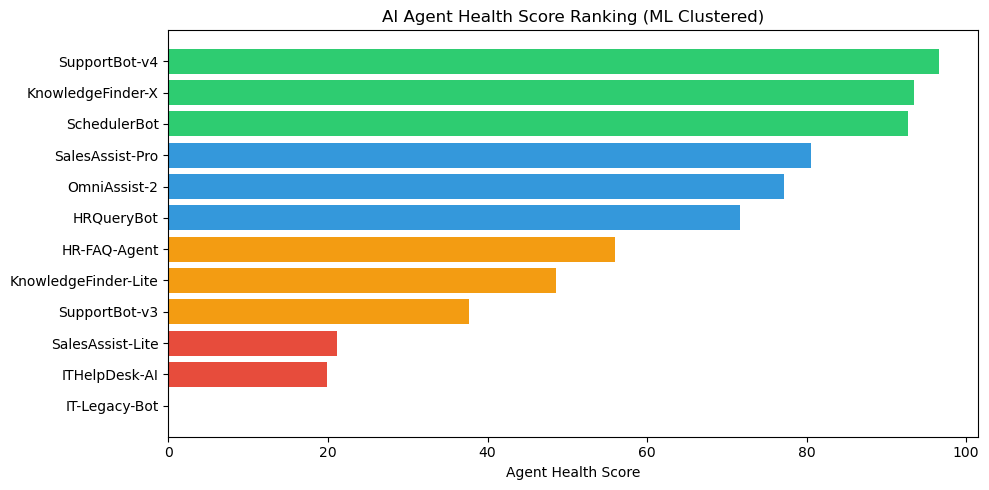

In [19]:
import matplotlib.pyplot as plt

colors = ["#2ecc71" if s == "Top Performer" else "#3498db" if s == "Solid Performer"
          else "#f39c12" if s == "Needs Improvement" else "#e74c3c"
          for s in agent["performance_status"]]

plt.figure(figsize=(10, 5))
plt.barh(agent["agent_name"], agent["agent_health_score"], color=colors)
plt.xlabel("Agent Health Score")
plt.title("AI Agent Health Score Ranking (ML Clustered)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("health_score_chart_ml.png", dpi=120)
plt.show()